In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pyod.utils.data import generate_data
from pyod.utils.example import visualize

from iforest import BAD_IForest
from pyod.models.iforest import IForest

X_train, X_test, y_train, y_test = generate_data(
    n_train=1000, n_test=100, contamination=0.1, random_state=0
)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
bforest = BAD_IForest().fit(X_train)
iforest = IForest().fit(X_train)

In [2]:
from bad import EnsembleBeliefs

bforest = BAD_IForest().fit(X_train)
bforest.beliefs = EnsembleBeliefs(
    np.stack([bforest.beliefs.a for _ in range(10)]),
    np.stack([bforest.beliefs.b for _ in range(10)]),
)

print("BAD_IForest predict shape:")
print(X_train.shape, " -> ", bforest.decision_function(X_train).shape)

print("BAD_IForest interest shape:")
print(X_train.shape, " -> ", bforest.interest(X_train).shape)

print("BAD_IForest update shape:")
bforest.update(X_train, y_train)
print(bforest.beliefs.a.shape, bforest.beliefs.b.shape)

BAD_IForest predict shape:
(1000, 2)  ->  (1000, 10)
BAD_IForest interest shape:
(1000, 2)  ->  (1000, 10)
BAD_IForest update shape:
(10, 100, 217) (10, 100, 217)


In [3]:
print("IForest fit time:")
%timeit IForest().fit(X_train)
print("IForest predict time:")
%timeit iforest.decision_function(X_test)

IForest fit time:
82.1 ms ± 499 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
IForest predict time:
1.32 ms ± 13.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [4]:
print("BAD_IForest fit time:")
%timeit BAD_IForest(reprocess_decision_scores=False).fit(X_train)
print("BAD_IForest predict time:")
%timeit bforest.decision_function(X_train)

print("BAD_IForest interest time:")
%timeit bforest.interest(X_train)
print("BAD_IForest update time:")
%timeit bforest.update(X_train, y_train)

BAD_IForest fit time:
97.3 ms ± 217 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
BAD_IForest predict time:
19.8 ms ± 28 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
BAD_IForest interest time:
22 ms ± 22.1 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
BAD_IForest update time:
36.3 ms ± 139 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


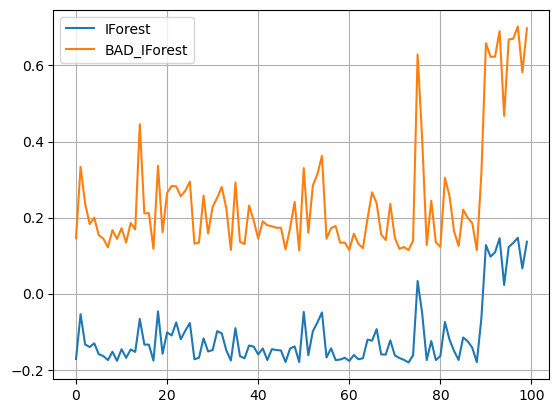

In [5]:
bforest = BAD_IForest().fit(X_train)
iforest = IForest().fit(X_train)
plt.plot(iforest.decision_function(X_test), label='IForest')
plt.plot(bforest.decision_function(X_test), label='BAD_IForest')
plt.legend()
plt.grid()
plt.show()

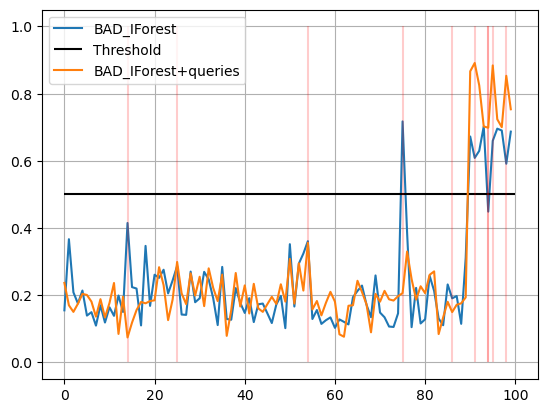

In [6]:
bforest = BAD_IForest().fit(X_train)
plt.plot(bforest.decision_function(X_test), label='BAD_IForest')
plt.hlines(bforest.threshold_, 0, len(X_test), "k", label='Threshold')

for i in range(10):
    scores = bforest.decision_function(X_test)
    i = np.argmin((scores-bforest.threshold_)**2)
    bforest.update(X_test[i:i+1], y_test[i:i+1])
    plt.vlines(i, 0, 1, "r", alpha=0.2)
plt.plot(bforest.decision_function(X_test), label='BAD_IForest+queries')
plt.legend()
plt.grid()
plt.show()